# Face-Swap-Aware Training (3-class)

This extends the original real/fake classifier to specifically call out FACE SWAPS as their own class, instead of lumping every manipulation method into one generic "fake" bucket.

Classes: `faceswap`, `other_fake` (Deepfakes / Face2Face / NeuralTextures), `real`

The FF++ download (`xdxd003/ff-c23`) is organized by manipulation method on Kaggle (`FaceForensics++_C23/Deepfakes/`, `.../FaceSwap/`, etc. -- see `01_dataset_download.ipynb`). 

To train this 3-class model we need the FaceSwap method downloaded separately, since `01_dataset_download.ipynb` currently only pulls `original/` and `Deepfakes/`.



In [15]:
from config import DATASETS_DIR, DATASETS_FACESWAP_DIR, SAVED_MODELS_DIR, REPORTS_DIR

Step 1 - Download the additional FaceSwap videos

Same pattern as `01_dataset_download.ipynb`, just targeting the `FaceSwap/` method folder instead of (or in addition to) `Deepfakes/`.

In [6]:
from kaggle.api.kaggle_api_extended import KaggleApi
import random
import os
from tqdm import tqdm
import time

api = KaggleApi()
api.authenticate()

dataset = "xdxd003/ff-c23"

all_files = []
page_token = None
while True:
    result = api.dataset_list_files(dataset, page_token=page_token, page_size=500)
    all_files.extend(result.files)
    page_token = result.next_page_token
    if not page_token:
        break

faceswap_files = [f.name for f in all_files if f.name.startswith("FaceForensics++_C23/FaceSwap/")]
print(f"FaceSwap videos found: {len(faceswap_files)}")
print(faceswap_files[:5])

FaceSwap videos found: 1000
['FaceForensics++_C23/FaceSwap/000_003.mp4', 'FaceForensics++_C23/FaceSwap/001_870.mp4', 'FaceForensics++_C23/FaceSwap/002_006.mp4', 'FaceForensics++_C23/FaceSwap/003_000.mp4', 'FaceForensics++_C23/FaceSwap/004_982.mp4']


In [7]:
random.seed(42)
SAMPLE_SIZE = 1000  # match the sample size used for original/Deepfakes in 01_dataset_download.ipynb

sampled_faceswap = random.sample(faceswap_files, min(SAMPLE_SIZE, len(faceswap_files)))
print(f"Selected {len(sampled_faceswap)} FaceSwap videos")

faceswap_dest = str(DATASETS_DIR / "raw_faceswap")
os.makedirs(faceswap_dest, exist_ok=True)

def download_with_retry(filenames, dest_folder, max_retries=3):
    existing = set(os.listdir(dest_folder))
    for filename in tqdm(filenames):
        local_name = filename.split("/")[-1]
        if local_name in existing:
            continue
        attempt = 0
        while attempt < max_retries:
            try:
                api.dataset_download_file(dataset, file_name=filename, path=dest_folder)
                break
            except Exception as e:
                attempt += 1
                if attempt == max_retries:
                    print(f"FAILED after {max_retries} attempts: {filename} -> {e}")
                else:
                    time.sleep(3)

print("Downloading FaceSwap videos...")
download_with_retry(sampled_faceswap, faceswap_dest)
print(f"FaceSwap videos on disk: {len(os.listdir(faceswap_dest))}")

Selected 1000 FaceSwap videos


100%|██████████| 1000/1000 [00:00<00:00, 982732.90it/s]

FaceSwap videos on disk: 1000


Step 2 - Extract frames from the FaceSwap videos

Identical logic to `02_preprocessing.ipynb` Step 2-3 (5 evenly-spaced frames per video) -- just pointed at the new `raw_faceswap` folder. Your existing `frames_real` and `frames_fake` (from Deepfakes) stay as they are; we only need a new `frames_faceswap` folder.

In [8]:
import cv2
import os
faceswap_dest = str(DATASETS_DIR / "raw_faceswap")
frames_faceswap = str(DATASETS_DIR / "frames_faceswap")
os.makedirs(frames_faceswap, exist_ok=True)
FRAMES_PER_VIDEO = 5

def extract_frames(video_path, output_folder, video_id, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return 0
    frame_indices = [int(i * total_frames / num_frames) for i in range(num_frames)]
    saved = 0
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if success:
            out_path = os.path.join(output_folder, f"{video_id}_frame{saved}.jpg")
            cv2.imwrite(out_path, frame)
            saved += 1
    cap.release()
    return saved

faceswap_videos = os.listdir(faceswap_dest)
total_saved = 0
for i, vid in enumerate(tqdm(faceswap_videos, desc="Extracting faceswap frames")):
    video_path = os.path.join(faceswap_dest, vid)
    saved = extract_frames(video_path, frames_faceswap, video_id=f"faceswap_{i}", num_frames=FRAMES_PER_VIDEO)
    total_saved += saved

print(f"Total faceswap frames saved: {total_saved}")

Extracting faceswap frames: 100%|██████████| 1000/1000 [26:00<00:00,  1.56s/it]   

Total faceswap frames saved: 4995


Step 3 - Face crop + resize (same Haar Cascade logic as `02_preprocessing.ipynb` Step 5-6)

Reuses the identical `crop_face` function -- consistency with your existing preprocessing matters here, since the "other_fake" class is built from your EXISTING `cropped_fake` folder (Deepfakes) plus this new faceswap crop step, and both need to have gone through the same preprocessing to be comparable.

In [9]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
IMG_SIZE = 224

def crop_face(image_path, output_path, img_size=IMG_SIZE):
    img = cv2.imread(image_path)
    if img is None:
        return "unreadable"
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) > 0:
        faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
        x, y, w, h = faces[0]
        face_crop = img[y:y+h, x:x+w]
        method = "face_crop"
    else:
        face_crop = img
        method = "full_frame"
    face_resized = cv2.resize(face_crop, (img_size, img_size))
    cv2.imwrite(output_path, face_resized)
    return method

cropped_faceswap = str(DATASETS_DIR / "cropped_faceswap")
os.makedirs(cropped_faceswap, exist_ok=True)

def process_folder(input_folder, output_folder):
    files = os.listdir(input_folder)
    counts = {"face_crop": 0, "full_frame": 0, "unreadable": 0}
    for f in tqdm(files, desc=f"Processing {input_folder}"):
        in_path = os.path.join(input_folder, f)
        out_path = os.path.join(output_folder, f)
        result = crop_face(in_path, out_path)
        counts[result] += 1
    return counts

faceswap_counts = process_folder(frames_faceswap, cropped_faceswap)
print(f"FaceSwap: {faceswap_counts}, total processed: {sum(faceswap_counts.values())} / {len(os.listdir(frames_faceswap))}")

Processing D:\Deepfake-detection\datasets\frames_faceswap: 100%|██████████| 4995/4995 [11:04<00:00,  7.52it/s]

FaceSwap: {'face_crop': 4971, 'full_frame': 24, 'unreadable': 0}, total processed: 4995 / 4995


Step 4 - Build the 3-class dataset

- `real` -> reuse your existing `cropped_real` folder as-is (untouched)
- `faceswap` -> the new `cropped_faceswap` folder from Step 3
- `other_fake` -> your existing `cropped_fake` folder (this was Deepfakes-only when you built it in `02_preprocessing.ipynb`, so it already represents "other manipulation methods" once FaceSwap becomes its own class)

Splits 70/15/15, matching the ratio in `02_preprocessing.ipynb` Step 8, but writing to a NEW `datasets_faceswap/` base folder so your original binary `datasets/train|validation|test` folders stay untouched and `03_model_training.ipynb` keeps working as-is.

In [10]:
import shutil
import random

random.seed(42)

dataset_base = str(DATASETS_DIR)
faceswap_dataset_base =str(DATASETS_FACESWAP_DIR)

def split_dataset(source_folder, dest_base, class_name, train_ratio=0.7, val_ratio=0.15):
    files = os.listdir(source_folder)
    random.shuffle(files)
    n = len(files)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]
    for split_name, split_files in [("train", train_files), ("validation", val_files), ("test", test_files)]:
        dest_folder = os.path.join(dest_base, split_name, class_name)
        os.makedirs(dest_folder, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(source_folder, f), os.path.join(dest_folder, f))
    print(f"{class_name}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

split_dataset(os.path.join(dataset_base, "cropped_real"), faceswap_dataset_base, "real")
split_dataset(os.path.join(dataset_base, "cropped_fake"), faceswap_dataset_base, "other_fake")
split_dataset(cropped_faceswap, faceswap_dataset_base, "faceswap")

real: train=3500, val=750, test=750
other_fake: train=3500, val=750, test=750
faceswap: train=3496, val=749, test=750


Step 5 - Train the 3-class EfficientNet-B0

Same architecture and optimizer settings as `03_model_training.ipynb` (Adam, lr=0.0001, CrossEntropyLoss) -- only the final layer width changes (2 -> 3). Saves to a NEW checkpoint name so `efficientnet_best.pth` (your binary model) is untouched.

**Check the printed `train_data.classes` line below against `FACESWAP_CLASS_NAMES` in `pipeline_core.py` before trusting any downstream prediction** -- this is exactly the kind of mismatch that silently breaks inference if missed.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)
faceswap_dataset_base = str(DATASETS_FACESWAP_DIR)

IMG_SIZE = 224
BATCH_SIZE = 8

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(f"{faceswap_dataset_base}/train", transform=transform)
val_data = datasets.ImageFolder(f"{faceswap_dataset_base}/validation", transform=transform)
test_data = datasets.ImageFolder(f"{faceswap_dataset_base}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("Classes:", train_data.classes)  # verify this matches FACESWAP_CLASS_NAMES in pipeline_core.py
print("Train size:", len(train_data), "Val size:", len(val_data), "Test size:", len(test_data))

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)  # 3 classes now, not 2
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cuda
Classes: ['faceswap', 'other_fake', 'real']
Train size: 10496 Val size: 2249 Test size: 2250


In [12]:
import os
import time
import torch

torch.set_num_threads(os.cpu_count())

ACCUMULATION_STEPS = 2
EPOCHS = 20
PATIENCE = 4
checkpoint_path = str(SAVED_MODELS_DIR / "efficientnet_faceswap_best.pth")
resume_path = str(SAVED_MODELS_DIR / "efficientnet_faceswap_resume.pth")

def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels) / ACCUMULATION_STEPS
        loss.backward()
        if (i + 1) % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
        running_loss += loss.item() * ACCUMULATION_STEPS * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    if (i + 1) % ACCUMULATION_STEPS != 0:
        optimizer.step()
        optimizer.zero_grad()
    return running_loss / total, correct / total

def validate():
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

start_epoch = 0
best_val_acc = 0.0
epochs_without_improvement = 0

if os.path.exists(resume_path):
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    print(f"Resuming from epoch {start_epoch} (best_val_acc so far: {best_val_acc:.4f})")

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
    }, resume_path)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"No improvement for {PATIENCE} epochs -- stopping early at epoch {epoch+1}.")
            break

print(f"Training complete. Best val_acc: {best_val_acc:.4f}")

Resuming from epoch 16 (best_val_acc so far: 0.9658)
Epoch 17/20 | Train Loss: 0.0217, Train Acc: 0.9923 | Val Loss: 0.1310, Val Acc: 0.9644 | Time: 224.9s
Epoch 18/20 | Train Loss: 0.0211, Train Acc: 0.9927 | Val Loss: 0.1793, Val Acc: 0.9529 | Time: 204.4s
Epoch 19/20 | Train Loss: 0.0141, Train Acc: 0.9953 | Val Loss: 0.1484, Val Acc: 0.9667 | Time: 215.3s
  -> New best model saved (val_acc=0.9667)
Epoch 20/20 | Train Loss: 0.0217, Train Acc: 0.9920 | Val Loss: 0.1622, Val Acc: 0.9631 | Time: 210.9s
Training complete. Best val_acc: 0.9667


Step 6 - Evaluate on the held-out test set

Same evaluation approach as `03_model_training.ipynb` Step 5-6, extended to a 3x3 confusion matrix. Pay particular attention to `faceswap` vs `other_fake` confusion -- those two classes are visually closer to each other than either is to `real`, so a higher off-diagonal count there is expected and worth reporting honestly rather than only looking at overall accuracy.

              precision    recall  f1-score   support

    faceswap       0.98      0.96      0.97       750
  other_fake       0.97      0.99      0.98       750
        real       0.97      0.96      0.97       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



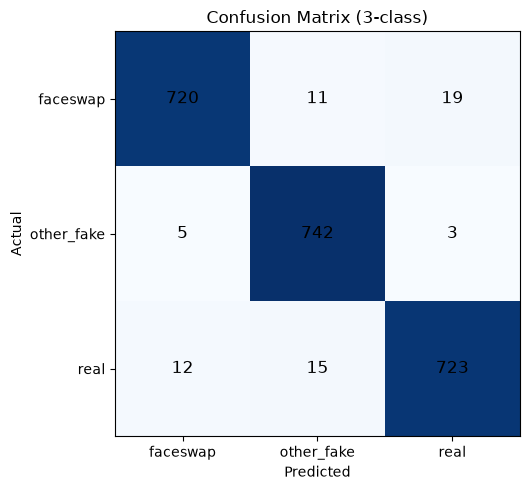

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same model architecture (model wasn't trained on this device/session)
model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)
model = model.to(device)

# Load trained weights
checkpoint_path = str(SAVED_MODELS_DIR / "efficientnet_faceswap_best.pth")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix (3-class)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(train_data.classes); ax.set_yticklabels(train_data.classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "faceswap_confusion_matrix.png"))
plt.show()